# 7. 역행렬

## 역행렬은 변환을 되돌리는 도구

- **배울 것**: 양쪽 역행렬, 왼쪽·오른쪽 역행렬, 의사역행렬, 조건수.

$$
A^{-1}A=AA^{-1}=I,\qquad \det(A)\ne0
$$

- 보통의 역행렬은 정사각 완전랭크 행렬에 존재합니다. 압축 과정에서 방향 하나가 사라졌다면 모든 입력을 복구할 수 없습니다.
- $A=\begin{bmatrix}1&4\\2&7\end{bmatrix}$의 행렬식은 $-1$이고 역행렬은 $\begin{bmatrix}-7&4\\2&-1\end{bmatrix}$입니다.
- `A*Ainv`는 원소별 곱입니다. 역행렬 검증에는 `A@Ainv`를 사용합니다.

## 직사각형 행렬은 한쪽에서만 되돌릴 수 있다

$$
L=(A^TA)^{-1}A^T,\quad LA=I_n\quad(m\ge n,\ \operatorname{rank}A=n)
$$
$$
R=A^T(AA^T)^{-1},\quad AR=I_m\quad(m\le n,\ \operatorname{rank}A=m)
$$

- 키 큰 완전열랭크 행렬은 왼쪽 역행렬을 가집니다. 반대 곱 $AL$은 전체 공간의 항등행렬이 아니라 열공간으로의 투영입니다.
- 가로로 긴 완전행랭크 행렬은 오른쪽 역행렬을 가집니다. 역시 곱하는 방향을 확인해야 합니다.
- 의사역행렬 $A^+$는 모든 행렬에 정의됩니다. 일반적으로 $AA^+=I$는 아니지만 $AA^+A=A$를 만족합니다.

## 계산이 성공해도 정확하다고 단정할 수 없다

$$
\kappa_2(A)=\frac{\sigma_{\max}}{\sigma_{\min}},\qquad
H_{ij}=\frac{1}{i+j-1}\quad(i,j\text{는 1부터})
$$

- 조건수가 크면 작은 입력 오차가 해에서 크게 확대될 수 있습니다. Hilbert 행렬은 크기가 커질수록 이런 현상을 잘 보여 줍니다.
- `inv`가 결과를 반환하는지와 재구성 오차가 작은지는 별개의 문제입니다. `norm(A@inv(A)-I)`와 조건수를 함께 확인합니다.
- $Ax=b$를 풀 때는 역행렬을 직접 만들기보다 `np.linalg.solve(A,b)`, 최소제곱에서는 `np.linalg.lstsq`를 사용합니다.
- **주의**: $(AB)^{-1}=B^{-1}A^{-1}$에서 순서가 바뀝니다. 직사각형 A에는 이 공식을 형식적으로 적용할 수 없습니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch07'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260932)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260932)

재현용 난수 시드: 20260932


### 코드 07-01

- 원본: `original_py/LA4DS_ch07.py` 1–7행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 역행렬

### 코드 07-02

- 원본: `original_py/LA4DS_ch07.py` 11–18행.

In [3]:
# a matrix
A = np.array([ [1,4],[2,7] ])

# its inverse
Ainv = np.linalg.inv(A)

# confirm that it produces the identity matrix
A@Ainv

Out[3]: 
array([[1., 0.],
       [0., 1.]])


### 코드 07-03

- 원본: `original_py/LA4DS_ch07.py` 20–52행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

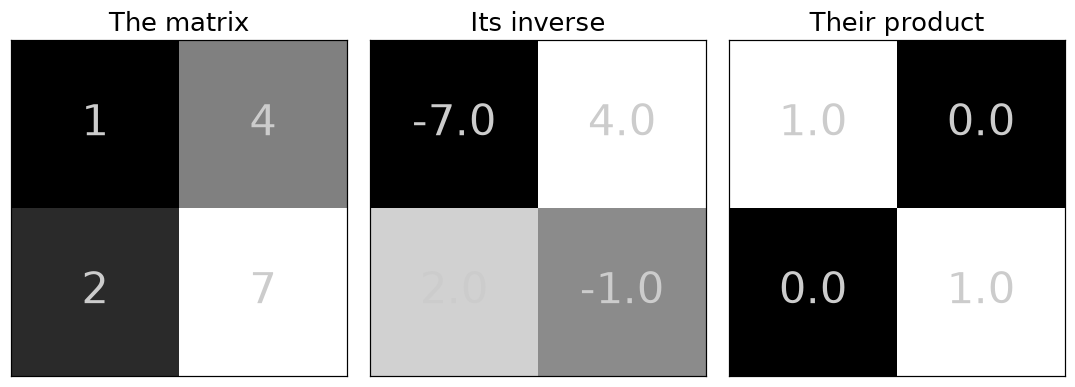

In [4]:
# The matrices visualized

fig,axs = plt.subplots(1,3,figsize=(10,6))


# the matrix
axs[0].imshow(A,cmap='gray')
axs[0].set_title('The matrix')
for (j,i),num in np.ndenumerate(A):
  axs[0].text(i,j,num,color=[.8,.8,.8],ha='center',va='center',fontsize=28)

# its inverse
axs[1].imshow(Ainv,cmap='gray')
axs[1].set_title('Its inverse')
for (j,i),num in np.ndenumerate(Ainv):
  axs[1].text(i,j,num,color=[.8,.8,.8],ha='center',va='center',fontsize=28)

# their product
AAi = A@Ainv
axs[2].imshow(AAi,cmap='gray')
axs[2].set_title('Their product')
for (j,i),num in np.ndenumerate(AAi):
  axs[2].text(i,j,num,color=[.8,.8,.8],ha='center',va='center',fontsize=28)


# common properties
for i in range(3):
  axs[i].set_xticks([])
  axs[i].set_yticks([])

plt.tight_layout()
plt.savefig(ASSET / 'Figure_07_01.png',dpi=140)
plt.show()

### 코드 07-04

- 원본: `original_py/LA4DS_ch07.py` 56–58행.

In [5]:
# the full inverse is two-sided
print( A@Ainv ), print(' ')
print( Ainv@A )

[[1. 0.]
 [0. 1.]]
 
[[1. 0.]
 [0. 1.]]


### 코드 07-05

- 원본: `original_py/LA4DS_ch07.py` 60–61행.

In [6]:
# reminder to use the correct operator:
A*Ainv # Hadamard multiplication!

Out[6]: 
array([[-7., 16.],
       [ 4., -7.]])


### 코드 07-06

- 원본: `original_py/LA4DS_ch07.py` 63–70행.
- **보완**: 의도된 오류를 해당 예외 타입으로 처리하고 오류 메시지를 출력합니다.

In [7]:
try:
    # try again with a singular matrix
    A = np.array([ [1,4],[2,8] ])

    # its inverse
    Ainv = np.linalg.inv(A)

    # does it produce the identity matrix?
    A@Ainv
except np.linalg.LinAlgError as exc:
    print("학습용 예상 오류:", type(exc).__name__, str(exc))

학습용 예상 오류: LinAlgError Singular matrix


### 대각행렬의 역행렬

### 코드 07-07

- 원본: `original_py/LA4DS_ch07.py` 74–84행.

In [8]:
D = np.diag( np.arange(1,6) )
Dinv = np.linalg.inv(D)

print('The diagonal matrix:')
print(D), print(' ')

print('Its inverse:')
print(Dinv), print(' ')

print('Their product:')
print(D@Dinv)

The diagonal matrix:
[[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]
 
Its inverse:
[[1.       0.       0.       0.       0.      ]
 [0.       0.5      0.       0.       0.      ]
 [0.       0.       0.333333 0.       0.      ]
 [0.       0.       0.       0.25     0.      ]
 [0.       0.       0.       0.       0.2     ]]
 
Their product:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


### 왼쪽 역행렬

### 코드 07-08

- 원본: `original_py/LA4DS_ch07.py` 88–101행.

In [9]:
# making an invertible square matrix from a tall full column-rank matrix

# here's a tall matrix.
T = np.random.randint(-10,11,size=(40,4))

# confirm that it has its maximum possible rank (full column-rank)
print( f'This matrix has rank={np.linalg.matrix_rank(T)}\n\n' )

# next, create a square full-rank matrix
TtT = T.T@T

# check whether it has an inverse
TtT_inv = np.linalg.inv(TtT)
print( np.round(TtT_inv@TtT,4) )

This matrix has rank=4


[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [-0. -0.  1. -0.]
 [-0. -0. -0.  1.]]


### 코드 07-09

- 원본: `original_py/LA4DS_ch07.py` 103–112행.

In [10]:
# finish creating the left-inverse

# our left-inverse
L = TtT_inv @ T.T

# confirm that it works
print( np.round( L@T,6 ) ), print(' ')

# but it's one-sided!
print( np.round( T@L,6 ) )

[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0. -0.  1. -0.]
 [-0. -0.  0.  1.]]
 
[[ 0.110061 -0.065033 -0.013763 ... -0.016837  0.134744  0.011334]
 [-0.065033  0.133329  0.016134 ...  0.010693 -0.06368   0.013231]
 [-0.013763  0.016134  0.064827 ... -0.033614  0.004032 -0.052193]
 ...
 [-0.016837  0.010693 -0.033614 ...  0.070633 -0.014594 -0.026166]
 [ 0.134744 -0.06368   0.004032 ... -0.014594  0.179899 -0.018839]
 [ 0.011334  0.013231 -0.052193 ... -0.026166 -0.018839  0.112252]]


### 코드 07-10

- 원본: `original_py/LA4DS_ch07.py` 115–137행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

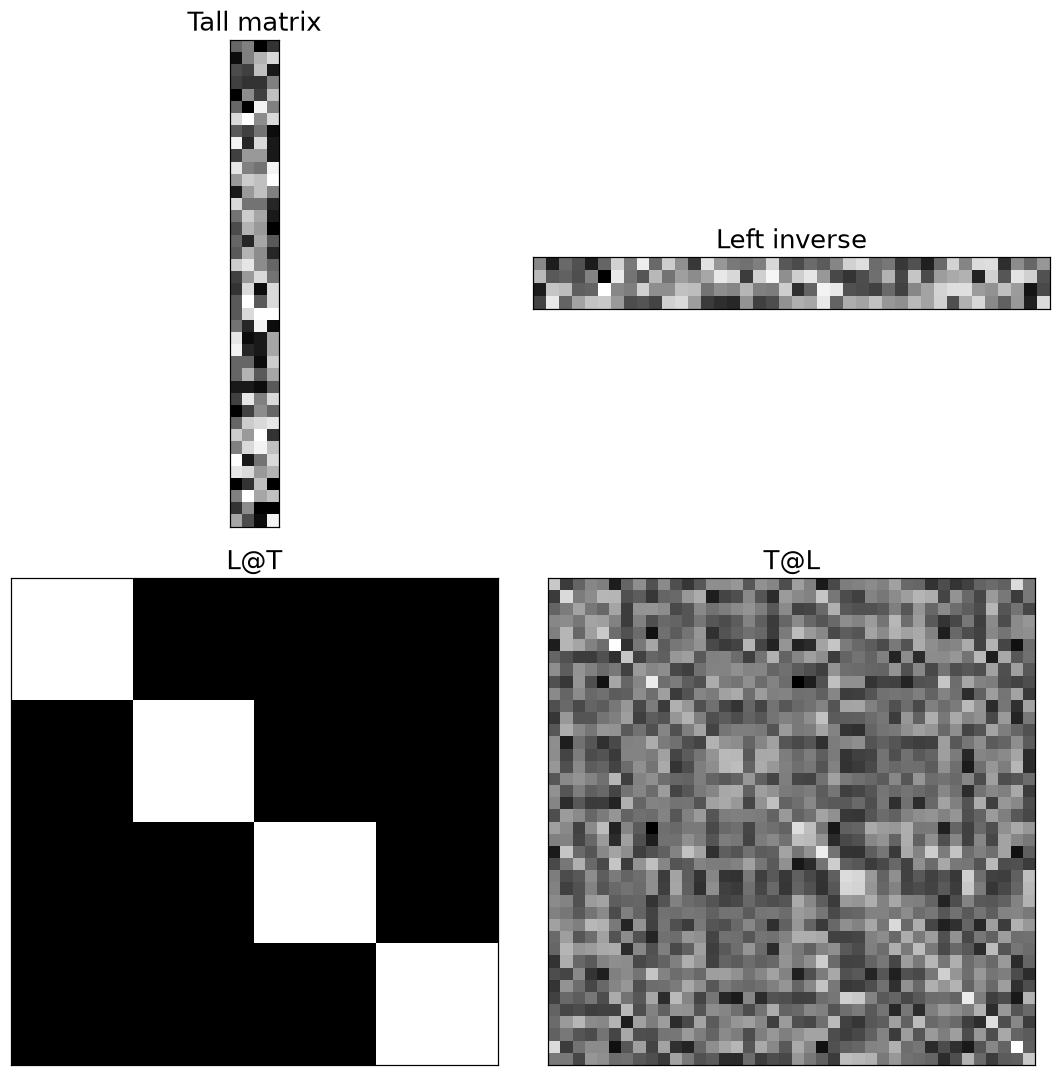

In [11]:
# visualize! of course :)

fig,axs = plt.subplots(2,2,figsize=(10,10))

axs[0,0].imshow(T,cmap='gray')
axs[0,0].set_title('Tall matrix')

axs[0,1].imshow(L,cmap='gray')
axs[0,1].set_title('Left inverse')

axs[1,0].imshow(L@T,cmap='gray')
axs[1,0].set_title('L@T')

axs[1,1].imshow(T@L,cmap='gray')
axs[1,1].set_title('T@L')

for a in axs.flatten():
  a.set_xticks([])
  a.set_yticks([])
  
plt.tight_layout()
plt.savefig(ASSET / 'Figure_07_04.png',dpi=140)
plt.show()

### 무어–펜로즈 의사역행렬

### 코드 07-11

- 원본: `original_py/LA4DS_ch07.py` 143–151행.

In [12]:
# The same singular matrix as before
A = np.array([ [1,4],[2,8] ])

# its inverse
Apinv = np.linalg.pinv(A)
print(Apinv*85), print(' ')

# does it produce the identity matrix?
A@Apinv

[[1. 2.]
 [4. 8.]]
 
Out[12]: 
array([[0.2, 0.4],
       [0.4, 0.8]])


### 코드 07-12

- 원본: `original_py/LA4DS_ch07.py` 153–161행.

The rank of this matrix is 5.



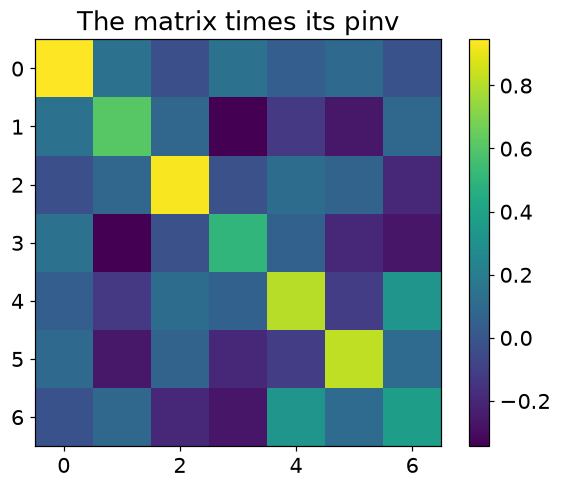

In [13]:
# an exmple with random numbers
A = np.random.randn(7,5) @ np.random.randn(5,7)
print(f'The rank of this matrix is {np.linalg.matrix_rank(A)}.\n')

Apinv = np.linalg.pinv(A)
plt.imshow(A@Apinv)
plt.title('The matrix times its pinv')
plt.colorbar()
plt.show()

## 연습문제 1 · 역행렬의 역행렬

- **목표**: $(A^{-1})^{-1}=A$를 확인합니다.
- **풀이 순서**: 임의 가역행렬의 역행렬을 두 번 구한 뒤 원본과 차이를 출력합니다.
- **결과 해석**: 0 근처 행렬입니다. 계산을 두 번 하므로 부동소수점 오차가 남을 수 있습니다.

### 코드 07-13

- 원본: `original_py/LA4DS_ch07.py` 165–175행.

In [14]:
n = 5

# the matrix
A = np.random.randn(n,n)

# its inverse, and its inverse's inverse
Ai  = np.linalg.inv(A)
Aii = np.linalg.inv(Ai)

# equal the original matrix within tolerance
np.round( A-Aii ,10)

Out[14]: 
array([[ 0., -0.,  0.,  0., -0.],
       [ 0., -0.,  0., -0., -0.],
       [-0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0., -0.],
       [ 0.,  0.,  0.,  0., -0.]])


## 연습문제 2 · 여인수로 역행렬 구현

- **목표**: 소행렬식·여인수·수반행렬 공식을 코드로 옮깁니다.
- **풀이 순서**: 행과 열 하나씩 제외한 소행렬식을 구하고 $(-1)^{i+j}$를 곱합니다. 여인수 행렬을 전치한 뒤 det(A)로 나눕니다.
- **결과 해석**: NumPy 역행렬과 일치합니다. 교육적으로 유용하지만 많은 행렬식을 계산해 큰 행렬에는 비효율적입니다. det가 0이면 사용할 수 없습니다.

### 코드 07-14

- 원본: `original_py/LA4DS_ch07.py` 179–215행.

In [15]:
# create matrix
m = 4
A = np.random.randn(m,m)

# initialize
M = np.zeros((m,m)) # minors matrix
G = np.zeros((m,m)) # grid matrix

# compute minors matrix
for i in range(m):
  for j in range(m):
    
    # select rows and cols
    rows = [True]*m
    rows[i] = False
    
    cols = [True]*m
    cols[j] = False
    
    # compute the minors
    M[i,j]=np.linalg.det(A[rows,:][:,cols])
    
    # compute Grid
    G[i,j] = (-1)**(i+j)

        
# compute cofactors matrix
C = M * G

# compute adjugate matrix
Ainv = C.T / np.linalg.det(A)

# 'regular' inverse function
AinvI = np.linalg.inv(A)

# compare against inv()
np.round( AinvI-Ainv ,8)

Out[15]: 
array([[-0., -0., -0., -0.],
       [ 0.,  0.,  0., -0.],
       [ 0., -0.,  0., -0.],
       [ 0., -0., -0., -0.]])


### 코드 07-15

- 원본: `original_py/LA4DS_ch07.py` 217–245행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

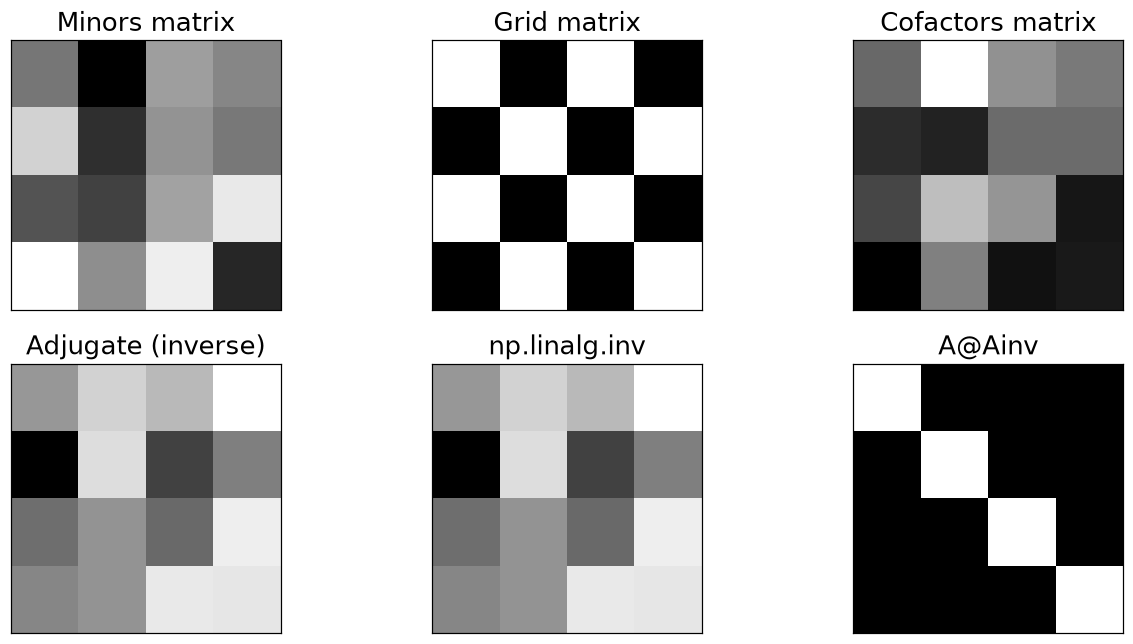

In [16]:
# plot them

fig,axs = plt.subplots(2,3,figsize=(14,7))

axs[0,0].imshow(M,cmap='gray')
axs[0,0].set_title('Minors matrix')

axs[0,1].imshow(G,cmap='gray')
axs[0,1].set_title('Grid matrix')

axs[0,2].imshow(C,cmap='gray')
axs[0,2].set_title('Cofactors matrix')

axs[1,0].imshow(Ainv,cmap='gray')
axs[1,0].set_title('Adjugate (inverse)')

axs[1,1].imshow(AinvI,cmap='gray')
axs[1,1].set_title('np.linalg.inv')

axs[1,2].imshow(A@Ainv,cmap='gray')
axs[1,2].set_title('A@Ainv')

for a in axs.flatten():
  a.set_xticks([])
  a.set_yticks([])


plt.savefig(ASSET / 'Figure_07_03.png',dpi=140)
plt.show()

## 연습문제 4 · 오른쪽 역행렬

- **목표**: 가로로 긴 행렬에서 역행렬 곱의 방향을 확인합니다.
- **풀이 순서**: 4×40 완전행랭크 W에 $R=W^T(WW^T)^{-1}$을 만듭니다. WR와 RW를 비교합니다.
- **결과 해석**: WR는 4×4 항등행렬, RW는 40×40 투영행렬입니다. 제공 노트북에는 연습문제 3 제목이 없으므로 없는 문제를 만들어 번호를 채우지 않았습니다.

### 코드 07-16

- 원본: `original_py/LA4DS_ch07.py` 249–262행.
- **보완**: 오른쪽 역행렬 예제의 rank 출력 대상 T를 W로 수정했습니다.

In [17]:
# Start from the code for the left-inverse, and swap as necessary.

# here's a wide matrix.
W = np.random.randint(-10,11,size=(4,40))

# confirm that it has its maximum possible rank (full column-rank)
print( f'This matrix has rank={np.linalg.matrix_rank(W)}\n\n' )

# next, create a square full-rank matrix
WWt = W@W.T

# check whether it has an inverse
WWt_inv = np.linalg.inv(WWt)
print( np.round(WWt_inv@WWt,4) )

This matrix has rank=4


[[ 1.  0. -0. -0.]
 [-0.  1.  0. -0.]
 [-0. -0.  1.  0.]
 [-0. -0. -0.  1.]]


### 코드 07-17

- 원본: `original_py/LA4DS_ch07.py` 264–273행.

In [18]:
# finish creating the right-inverse

# our left-inverse
R = W.T @ WWt_inv

# confirm that it works
print( np.round( W@R,6 ) ), print(' ')

# but it's one-sided!
print( np.round( R@W,6 ) )

[[ 1.  0. -0.  0.]
 [ 0.  1.  0. -0.]
 [ 0.  0.  1. -0.]
 [-0. -0. -0.  1.]]
 
[[ 0.162073 -0.048797 -0.095123 ...  0.054961  0.000356  0.062116]
 [-0.048797  0.076872 -0.013738 ... -0.06426   0.029783 -0.067264]
 [-0.095123 -0.013738  0.095237 ... -0.029004 -0.043447  0.003286]
 ...
 [ 0.054961 -0.06426  -0.029004 ...  0.232134  0.093595  0.033887]
 [ 0.000356  0.029783 -0.043447 ...  0.093595  0.093269 -0.040943]
 [ 0.062116 -0.067264  0.003286 ...  0.033887 -0.040943  0.066301]]


### 코드 07-18

- 원본: `original_py/LA4DS_ch07.py` 276–297행.

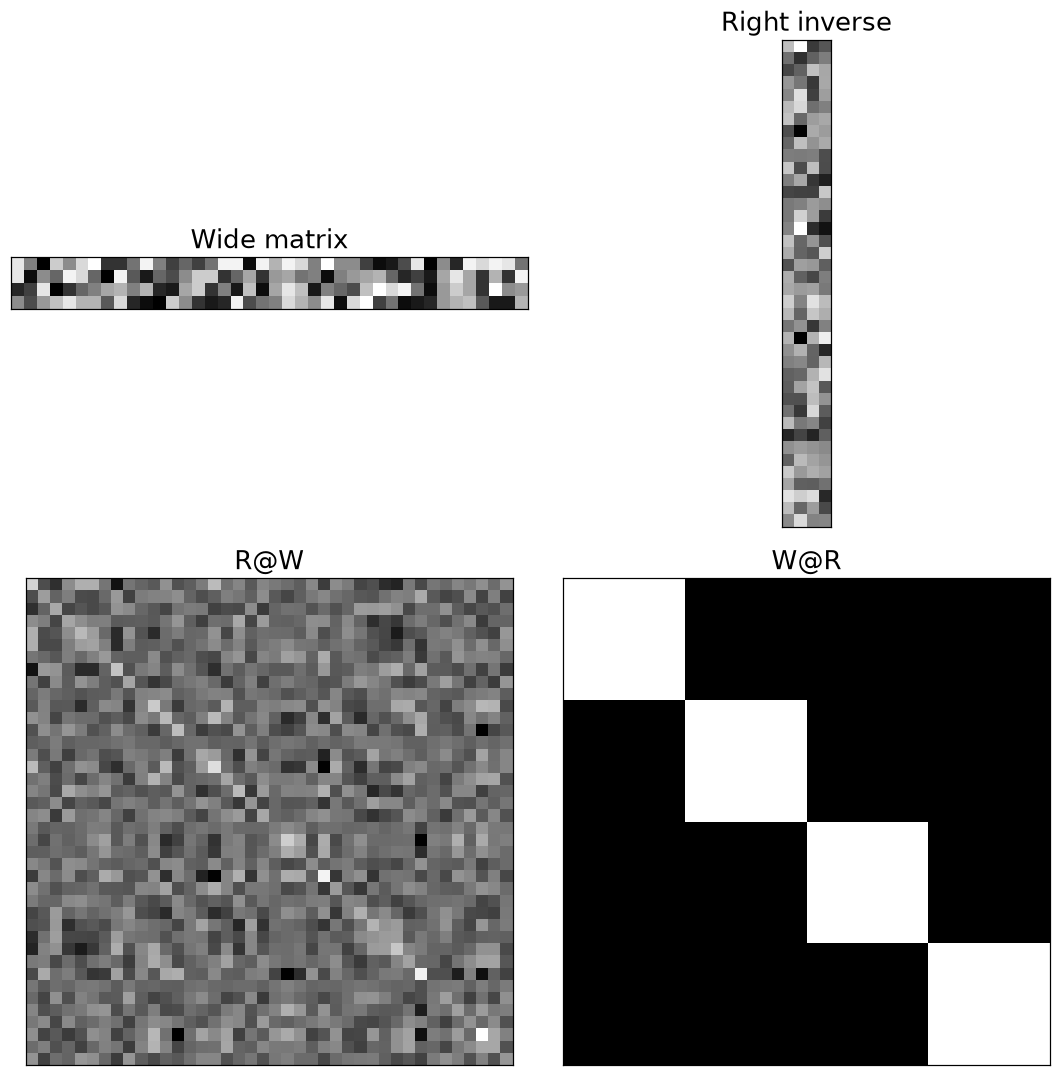

In [19]:
# visualize! of course :)

fig,axs = plt.subplots(2,2,figsize=(10,10))

axs[0,0].imshow(W,cmap='gray')
axs[0,0].set_title('Wide matrix')

axs[0,1].imshow(R,cmap='gray')
axs[0,1].set_title('Right inverse')

axs[1,0].imshow(R@W,cmap='gray')
axs[1,0].set_title('R@W')

axs[1,1].imshow(W@R,cmap='gray')
axs[1,1].set_title('W@R')

for a in axs.flatten():
  a.set_xticks([])
  a.set_yticks([])
  
plt.tight_layout()
plt.show()

## 연습문제 5 · 의사역행렬과 기존 역행렬

- **목표**: pinv가 가역·완전열랭크·완전행랭크 경우를 통합함을 확인합니다.
- **풀이 순서**: 정사각·키 큰·가로 긴 행렬에서 각 명시적 역행렬 공식과 pinv의 차이를 구합니다.
- **결과 해석**: 성립 조건을 만족하면 차이는 0 근처입니다. 랭크가 부족하면 일반 공식은 실패해도 pinv는 정의됩니다.

### 코드 07-19

- 원본: `original_py/LA4DS_ch07.py` 301–309행.

In [20]:
# Full inverse case
M = 4

A = np.random.randn(M,M)

Ainv  = np.linalg.inv(A)
Apinv = np.linalg.pinv(A)

np.round( Ainv-Apinv,10 )

Out[20]: 
array([[ 0.,  0., -0., -0.],
       [ 0., -0.,  0., -0.],
       [-0.,  0., -0.,  0.],
       [ 0., -0., -0., -0.]])


### 코드 07-20

- 원본: `original_py/LA4DS_ch07.py` 311–319행.

In [21]:
# left inverse case
M,N = 14,4

A = np.random.randn(M,N)

ALeft = np.linalg.inv(A.T@A) @ A.T
Apinv = np.linalg.pinv(A)

np.round( ALeft-Apinv,10 )

Out[21]: 
array([[-0., -0.,  0.,  0.,  0.,  0., -0., -0.,  0., -0., -0.,  0.,  0.,
         0.],
       [ 0., -0.,  0., -0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0., -0.,
         0.],
       [ 0., -0., -0., -0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0., -0.,
        -0.],
       [ 0., -0.,  0., -0.,  0.,  0., -0.,  0.,  0.,  0., -0.,  0., -0.,
         0.]])


### 코드 07-21

- 원본: `original_py/LA4DS_ch07.py` 321–329행.

In [22]:
# right inverse case
M,N = 4,14

A = np.random.randn(M,N)

ARight = A.T @ np.linalg.inv(A@A.T)
Apinv  = np.linalg.pinv(A)

np.round( ARight-Apinv,10 )

Out[22]: 
array([[-0., -0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0., -0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [-0.,  0., -0.,  0.],
       [ 0.,  0., -0., -0.],
       [ 0.,  0., -0., -0.],
       [-0., -0., -0., -0.],
       [-0.,  0.,  0.,  0.],
       [ 0., -0.,  0.,  0.]])


## 연습문제 6 · 곱의 역행렬 순서

- **목표**: $(AB)^{-1}$의 올바른 순서를 찾습니다.
- **풀이 순서**: inv(AB)를 inv(A)inv(B), inv(B)inv(A)와 각각 비교해 거리를 출력합니다.
- **결과 해석**: 역순 곱과의 거리만 0 근처입니다. 일반 행렬은 교환법칙이 없으므로 순서가 핵심입니다.

### 코드 07-22

- 원본: `original_py/LA4DS_ch07.py` 333–349행.

In [23]:
# create the matrices
N = 4
A = np.random.randn(N,N)
B = np.random.randn(N,N)

# compute the three specified options
op1 = np.linalg.inv(A@B)
op2 = np.linalg.inv(A) @ np.linalg.inv(B)
op3 = np.linalg.inv(B) @ np.linalg.inv(A)

# compute distances
dist12 = np.sqrt(np.sum( (op1-op2)**2 ))
dist13 = np.sqrt(np.sum( (op1-op3)**2 ))

# print results!
print(f'Distance between (AB)^-1 and (A^-1)(B^-1) is {dist12:.8f}')
print(f'Distance between (AB)^-1 and (B^-1)(A^-1) is {dist13:.8f}')

Distance between (AB)^-1 and (A^-1)(B^-1) is 63.05969005
Distance between (AB)^-1 and (B^-1)(A^-1) is 0.00000000


## 연습문제 7 · 직사각형에 역행렬 규칙 오용

- **목표**: $(T^TT)^{-1}$를 존재하지 않는 역행렬들의 곱으로 나눌 수 없음을 확인합니다.
- **풀이 순서**: 키 큰 T에서 Gram 행렬 역행렬은 구한 뒤 inv(T)를 시도합니다.
- **결과 해석**: 정사각형이 아니라는 LinAlgError가 예상 결과입니다. T 자체의 역행렬이 없으므로 해당 분해는 유효하지 않습니다.

### 코드 07-23

- 원본: `original_py/LA4DS_ch07.py` 353–361행.
- **보완**: 의도된 오류를 해당 예외 타입으로 처리하고 오류 메시지를 출력합니다.

In [24]:
try:
    # create the matrices
    M,N = 14,4
    T = np.random.randn(M,N)

    # compute the three specified options
    op1 = np.linalg.inv(T.T@T)
    op2 = np.linalg.inv(T) @ np.linalg.inv(T.T)

    # The answer is No, it doesn't work, because a tall matrix has no inverse.
except np.linalg.LinAlgError as exc:
    print("학습용 예상 오류:", type(exc).__name__, str(exc))

학습용 예상 오류: LinAlgError Last 2 dimensions of the array must be square


## 연습문제 8 · 변환을 역행렬로 되돌리기

- **목표**: 원→타원→원 복원을 시각화합니다.
- **풀이 순서**: 단위원 점에 T를 적용한 후 Ti를 다시 곱합니다. 세 점 집합을 함께 그립니다.
- **결과 해석**: 원본 점과 복원 점이 겹칩니다. 정확한 확인은 `allclose(Ti@T@points,points)`로 할 수 있습니다.

### 코드 07-24

- 원본: `original_py/LA4DS_ch07.py` 365–399행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<ipython-input-25-ec0ef39cda19>:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx" (-> color='r'). The keyword argument will take precedence.
  plt.plot(backTransformed[0,:],backTransformed[1,:],'rx',markersize=15,


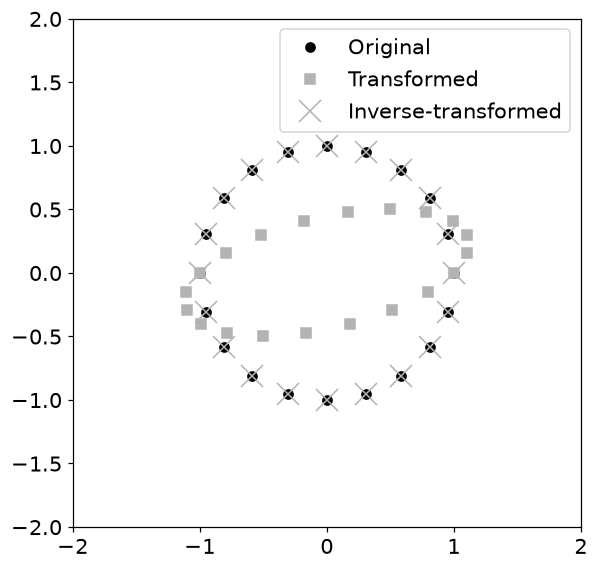

In [25]:
# Transformation matrix
T = np.array([ 
              [1,.5],
              [0,.5]
            ])

# Compute its inverse
Ti = np.linalg.inv(T)


# define the set of points (a circle)
theta = np.linspace(0,2*np.pi-2*np.pi/20,20)
origPoints = np.vstack( (np.cos(theta),np.sin(theta)) )

# apply transformation
transformedPoints = T @ origPoints

# undo the transformation via the inverse of the transform
backTransformed   = Ti @ transformedPoints


# plot the points
plt.figure(figsize=(6,6))
plt.plot(origPoints[0,:],origPoints[1,:],'ko',label='Original')
plt.plot(transformedPoints[0,:],transformedPoints[1,:],'s',
         color=[.7,.7,.7],label='Transformed')
plt.plot(backTransformed[0,:],backTransformed[1,:],'rx',markersize=15,
         color=[.7,.7,.7],label='Inverse-transformed')

plt.axis('square')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.legend()
plt.savefig(ASSET / 'Figure_07_06.png',dpi=140)
plt.show()

## 연습문제 9 · Hilbert 행렬 만들기

- **목표**: 수학식의 1기반 인덱스를 Python으로 변환합니다.
- **풀이 순서**: 0기반 i,j에서는 $1/(i+j+1)$을 사용합니다. 이중 루프·브로드캐스팅·SciPy 함수를 비교합니다.
- **결과 해석**: 세 방법이 같은 행렬을 만듭니다. 역행렬 원소는 매우 커질 수 있어 입력이 매끄럽다고 역행렬도 안정적인 것은 아닙니다.

### 코드 07-25

- 원본: `original_py/LA4DS_ch07.py` 403–422행.

In [26]:
# a function to create a Hilbert matrix
def hilbmat(k):
  H = np.zeros((k,k))
  for i in range(k):
    for j in range(k):

      # note: the math formula has denominator: i+j-1
      #   but with 0-based indexing, this is: (i+1)+(j+1)-1
      #   which can be shortened to: i+j+1

      H[i,j] = 1 / (i+j+1)
  return H

  

# The double for-loop above is a direct implementation of the math.
# The function below gives the same result but without the loops.
def hilbmat(k):
  k = np.arange(1,k+1).reshape(1,-1) # reshape to a row vector (instead of a 1D array)
  return 1 / (k.T+k-1) # outer product and element-wise division

### 코드 07-26

- 원본: `original_py/LA4DS_ch07.py` 424–428행.

In [27]:
print( hilbmat(5) ), print(' ')

# you can confirm the accuracy of your function against the scipy Hilbert-matrix function:
from scipy.linalg import hilbert
print( hilbert(5) )

[[1.       0.5      0.333333 0.25     0.2     ]
 [0.5      0.333333 0.25     0.2      0.166667]
 [0.333333 0.25     0.2      0.166667 0.142857]
 [0.25     0.2      0.166667 0.142857 0.125   ]
 [0.2      0.166667 0.142857 0.125    0.111111]]
 
[[1.       0.5      0.333333 0.25     0.2     ]
 [0.5      0.333333 0.25     0.2      0.166667]
 [0.333333 0.25     0.2      0.166667 0.142857]
 [0.25     0.2      0.166667 0.142857 0.125   ]
 [0.2      0.166667 0.142857 0.125    0.111111]]


### 코드 07-27

- 원본: `original_py/LA4DS_ch07.py` 430–457행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

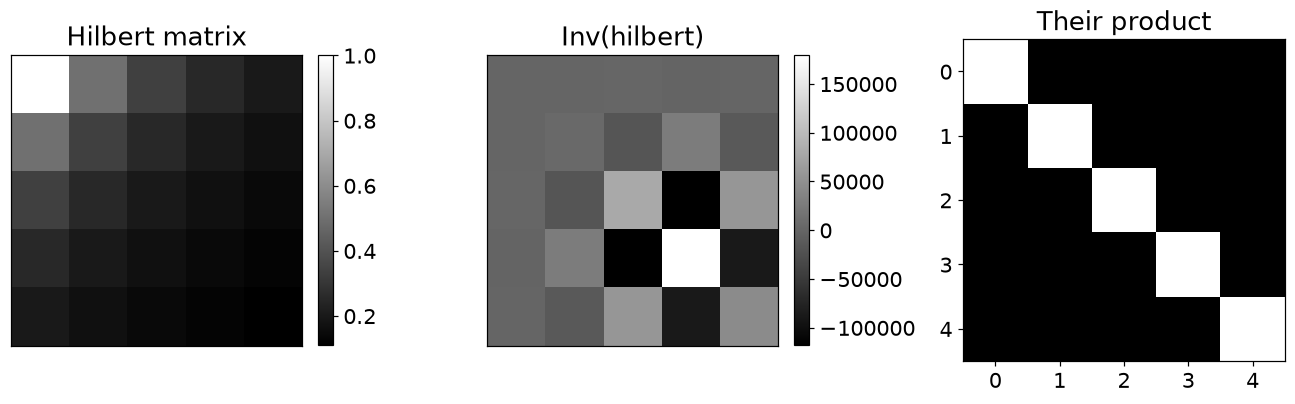

In [28]:
# create a 5x5 Hilbert matrix and show it, its inverse, and their product
H = hilbmat(5)
Hi = np.linalg.inv(H)

fig,axs = plt.subplots(1,3,figsize=(12,6))
h = [0,0,0]

# the matrix
h[0] = axs[0].imshow(H,cmap='gray')
axs[0].set_title('Hilbert matrix')

# its inverse
h[1] = axs[1].imshow(Hi,cmap='gray')
axs[1].set_title('Inv(hilbert)')

# their product
h[2] = axs[2].imshow(H@Hi,cmap='gray')
axs[2].set_title('Their product')


for i in range(2):
  fig.colorbar(h[i],ax=axs[i],fraction=.045)
  axs[i].set_xticks([])
  axs[i].set_yticks([])

plt.tight_layout()
plt.savefig(ASSET / 'Figure_07_05.png',dpi=140)
plt.show()

## 연습문제 10 · 조건수와 역행렬 오차

- **목표**: Hilbert 행렬과 난수행렬의 민감도를 비교합니다.
- **풀이 순서**: 크기 3~12에서 조건수와 $\|HH^{-1}-I\|_F$를 구해 로그로 그립니다.
- **결과 해석**: Hilbert의 조건수와 오차가 대체로 훨씬 큽니다. 조건수는 최악의 증폭 가능성이므로 모든 표본에서 오차가 정확히 비례할 필요는 없습니다.

### 코드 07-28

- 원본: `original_py/LA4DS_ch07.py` 462–517행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

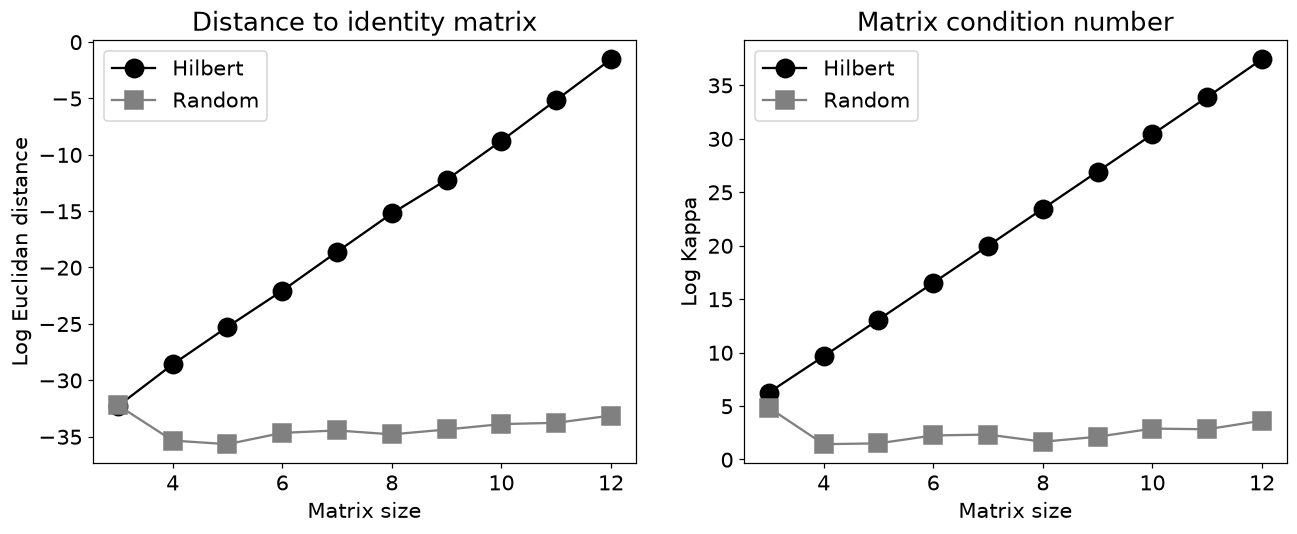

In [29]:
matSizes = np.arange(3,13)

identityError = np.zeros((len(matSizes),2))
condNumbers   = np.zeros((len(matSizes),2))


for i,k in enumerate(matSizes):
    
    ### for the Hilbert matrix
    H   = hilbmat(k)       # the matrix
    Hi  = np.linalg.inv(H) # its inverse
    HHi = H@Hi             # should be identity
    err = HHi - np.eye(k)  # difference from true identity
    identityError[i,0] = np.sqrt(np.sum(err**2))  # Euclidean distance
    condNumbers[i,0] = np.linalg.cond(H) # condition number
    

    ### repeat for a random matrix
    H = np.random.randn(k,k) # the matrix
    Hi  = np.linalg.inv(H)   # its inverse
    HHi = H@Hi               # should be identity
    err = HHi - np.eye(k)    # difference from true identity
    identityError[i,1] = np.sqrt(np.sum(err**2))  # Euclidean distance
    condNumbers[i,1] = np.linalg.cond(H) # condition number
    


# now plot
fig,axs = plt.subplots(1,2,figsize=(14,5))

## plot the Euclidean distance to the identity matrix
h = axs[0].plot(matSizes,np.log(identityError),'s-',markersize=12)
h[0].set_color('k') # adjust the individual line colors and shapes
h[0].set_marker('o')
h[1].set_color('gray')

axs[0].legend(['Hilbert','Random'])
axs[0].set_xlabel('Matrix size')
axs[0].set_ylabel('Log Euclidan distance')
axs[0].set_title('Distance to identity matrix')



## plot the condition numbers
h = axs[1].plot(matSizes,np.log(condNumbers),'s-',markersize=12)
h[0].set_color('k') # adjust the individual line colors and shapes
h[0].set_marker('o')
h[1].set_color('gray')

axs[1].legend(['Hilbert','Random'])
axs[1].set_xlabel('Matrix size')
axs[1].set_ylabel('Log Kappa')
axs[1].set_title('Matrix condition number')

plt.savefig(ASSET / 'Figure_07_07.png',dpi=140)
plt.show()

### 코드 07-29

- 원본: `original_py/LA4DS_ch07.py` 519–526행.

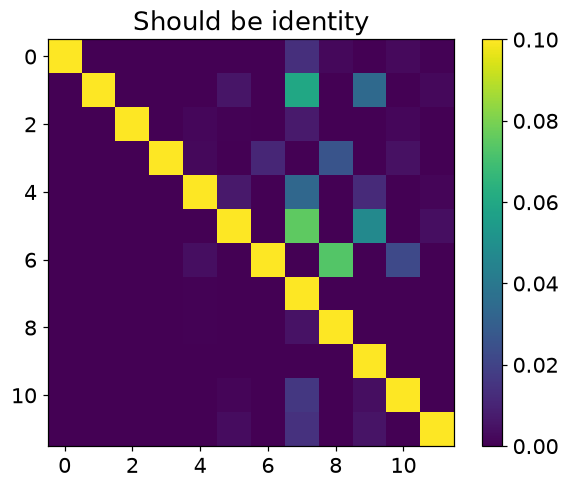

In [30]:
## interesting to see the "identity" matrix
H   = hilbmat(k)
Hi  = np.linalg.inv(H)
HHi = H@Hi 

plt.imshow(HHi,vmin=0,vmax=.1)
plt.title('Should be identity')
plt.colorbar();

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [31]:
_A=np.array([[1.,4.],[2.,7.]])
_Ai=np.linalg.inv(_A)
print('역행렬:\n',_Ai)
assert np.allclose(_A@_Ai,np.eye(2))
_S=np.array([[1.,4.],[2.,8.]]); _P=np.linalg.pinv(_S)
print('AA+ (항등행렬이 아닌 투영):\n',_S@_P)
assert np.allclose(_S@_P@_S,_S)
assert np.allclose((_S@_P).T,_S@_P)


역행렬:
 [[-7.  4.]
 [ 2. -1.]]
AA+ (항등행렬이 아닌 투영):
 [[0.2 0.4]
 [0.4 0.8]]
